In [90]:
from pathlib import Path
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv
# DATASET_NAME = "suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset"
# PROJECT_NAME ="76_90000_samples_animal_206" # 75_10000_samples_hopefully_no_lost_entries_gamma_minus0p1_to_1_animal_206_identical_version_just_without_minus_etc" # 76_90000_samples_animal_206" # 04_big_overnight_run" # 1_first_bigger_run_animal_0" # 76_90000_samples_animal_206" # 60_generally_finer_search_animal_0" # 26_testing_4_KS_folders_why_so_fast" # #  "2423_24rough_combined" # 24_testing_4_KS_folders_rougher_grid" # 20_sweep_with_individual_connectomes_eta_-7_and_gamma_-0.2"
DATASET_NAME = "hcp_schaefer_100_dataset" # suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset"
PROJECT_NAME = "05_second_big_overnight_run_10201" # 76_90000_samples_animal_206"
# mode = "portrait" # "energy"
# mode = "energy"
# mode = "f1"
mode = "communicability"
base_output_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output")
project_path = base_output_path / "gnm" / DATASET_NAME / PROJECT_NAME
save_path_divergence = project_path / "figures_accuracy"

save_path_divergence.mkdir(parents=True, exist_ok=True)

In [91]:
# from notebook_setup import setup
from vizman import viz
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

# from kaysons_visual_config import * # Kayson's file. 
from pypalettes import load_cmap
cmap = load_cmap("Aurora")

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome


import pandas as pd
import seaborn as sns

In [92]:
# file_emp_connectome_estimated_eta_and_gamma = project_path / "min_energy_results.csv"
if mode == "f1" or mode == "communicability": 
    file_emp_connectome_estimated_eta_and_gamma = project_path / f"max_{mode}_results.csv" 
    df_best_eta_gamma = pd.read_csv(file_emp_connectome_estimated_eta_and_gamma)
    
elif mode == "portrait" or mode == "energy":
    file_emp_connectome_estimated_eta_and_gamma = project_path / f"min_{mode}_results.csv"  
    df_best_eta_gamma = pd.read_csv(file_emp_connectome_estimated_eta_and_gamma)

# file_emp_connectome_estimated_eta_and_gamma = project_path / f"min_{"energy"}_results.csv"
# df_best_eta_gamma_energies = pd.read_csv(file_emp_connectome_estimated_eta_and_gamma)

df_metrics = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/all_metrics_for_{PROJECT_NAME}.csv") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/01_first_bigger_run_animal_0/all_metrics_for_01_first_bigger_run_animal_0.csv")
df_portraits = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_portrait_for_exp_{PROJECT_NAME}.csv")
df_energies = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_energies_for_exp_{PROJECT_NAME}.csv")
df_f1 = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_f1_for_exp_{PROJECT_NAME}.csv")
df_communicability = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_communicability_for_exp_{PROJECT_NAME}.csv")
    
id = 1

if mode == "portrait":
    df = df_portraits.copy() 
    important_parameter = f"PortraitDiv_indiv_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
elif mode == "f1":
    df = df_f1.copy()
    df[f"One_minus_F1Crit_subject_{id}"] = (1 - df["F1Crit_subject_1"])
    important_parameter = f"One_minus_F1Crit_subject_{id}"
elif mode == "communicability":
    df = df_communicability.copy()
    important_parameter = f"CommCorr_subject_{id}"
    # df[f"One_minus_CommCorr_subject_{id}"] = (1 - df["CommCorr_subject_1"])
else:
    print("Mode not recognized")


In [93]:
lowest_energies = df.nsmallest(3, important_parameter)[["eta", "gamma", "filename", important_parameter]]
print(lowest_energies)

        eta  gamma                                           filename  \
5894   0.03 -0.067  net_eta0.030000016093254_gamma-0.0670000016689...   
10033 -3.49  0.945  net_eta-3.490000009536743_gamma0.9449999928474...   
62    -5.14  0.758  net_eta-5.139999866485596_gamma0.7580000162124...   

       CommCorr_subject_1  
5894            -0.294910  
10033           -0.294889  
62              -0.293599  


In [94]:


if DATASET_NAME == "hcp_schaefer_100_dataset":
    empirical_connectome = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/00_connectomes_density10.npy")
    empirical_connectome = empirical_connectome[id,:,:]
    
elif DATASET_NAME == "suarez_MaMI_dataset":
    # empirical_connectome = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_density10.npy")
    # empirical_connectome = empirical_connectome[id,:,:]
    pass

In [95]:
lowest_energies

,eta,gamma,filename,CommCorr_subject_1
5894,0.03,-0.067,net_eta0.030000016093254_gamma-0.0670000016689...,-0.294910
10033,-3.49,0.945,net_eta-3.490000009536743_gamma0.9449999928474...,-0.294889
62,-5.14,0.758,net_eta-5.139999866485596_gamma0.7580000162124...,-0.293599


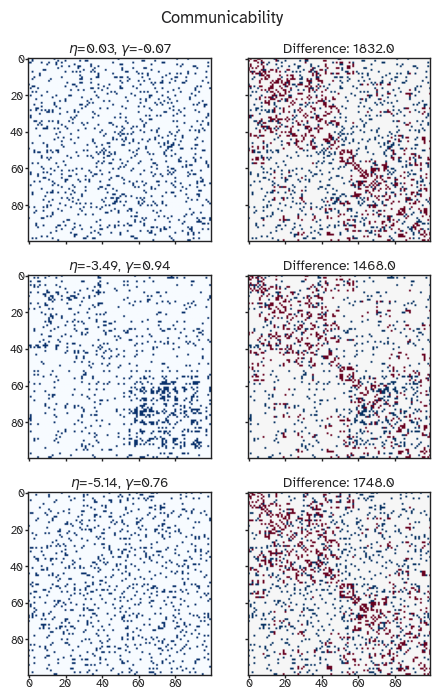

In [96]:
diff_results = []

fig, axes = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(viz.cm_to_inch((12,18))))
    # axes = axes.flatten()

for i, row in enumerate(lowest_energies.itertuples()):
    # Load the numpy array from the filename
    data = np.load(project_path / "generated_networks" / row.filename)[0,:,:]

    # Plot the data
    ax = axes[i, 0]
    im = ax.imshow(data, cmap="Blues")
    # ax.set_title(f"Network {row.network_index} (eta={np.round(row.eta,2)}, gamma={np.round(row.gamma,2)})")
    ax.set_title(r"$\eta$" + f"={np.round(row.eta,2)}, " + r"$\gamma$" + f"={np.round(row.gamma,2)}")
    # fig.colorbar(im, ax=ax)
        # axes["landscape"].set_xlabel(r"$\eta$", fontsize=12)
        # axes["landscape"].set_ylabel(r"$\gamma$", fontsize=12)
    # Subtract empirical_connectome and plot in the right column
    ax_diff = axes[i, 1]
    diff_data = data - empirical_connectome
    im_diff = ax_diff.imshow(diff_data, cmap="RdBu", vmin=-np.max(np.abs(diff_data)), vmax=np.max(np.abs(diff_data)))
    # ax_diff.set_title(f"Difference: {np.round(np.mean(np.abs(diff_data)), 2)}") #  (Network {row.network_index})")
    ax_diff.set_title(f"Difference: {np.round(np.sum(np.abs(diff_data)), 2)}") #  (Network {row.network_index})")

    # fig.colorbar(im_diff, ax=ax_diff)

    # # Save the subtraction result in an array
    # if i == 0:
    #     diff_results = np.zeros((len(lowest_energies), *diff_data.shape))
    diff_results.append(diff_data)
    # im = ax.imshow(data, cmap="Blues")
    # ax.set_title(f"Network {row.network_index} (eta={row.eta}, gamma={row.gamma})")
    # fig.colorbar(im, ax=ax)

plt.suptitle(f"{mode.capitalize()}") # , fontsize=16)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Gamma')

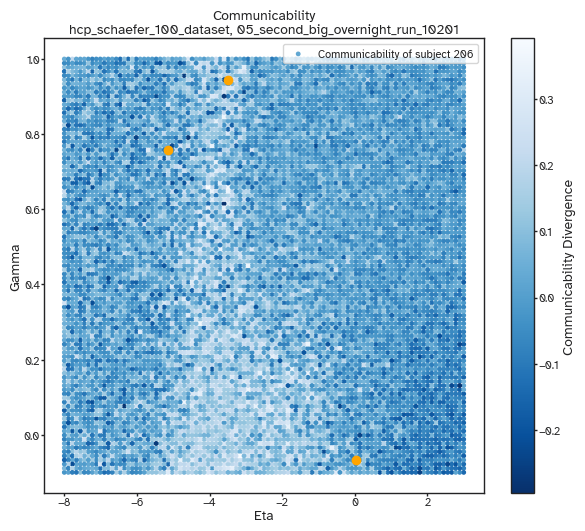

In [101]:
plt.figure(figsize=(viz.cm_to_inch((18,15))))

id = 1

if mode == "portrait":
    df = df_portraits.copy() 
    important_parameter = f"PortraitDiv_indiv_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
elif mode == "f1":
    df = df_f1.copy()
    df[f"One_minus_F1Crit_subject_{id}"] = (1 - df["F1Crit_subject_1"])
    important_parameter = f"One_minus_F1Crit_subject_{id}"
elif mode == "communicability":
    df = df_communicability.copy() # * (-1)  # So that higher is better
    df[f"Minus_CommCorr_subject_{id}"] = df["CommCorr_subject_1"] # (- df["CommCorr_subject_1"])
    important_parameter = f"Minus_CommCorr_subject_{id}"
    # df[f"One_minus_CommCorr_subject_{id}"] = (1 - df["CommCorr_subject_1"])
else: 
    print("Mode not recognized")

df_avg = df.groupby(['eta', 'gamma'], as_index=False).agg({
    important_parameter: 'mean'
})

cmap = plt.get_cmap("Blues")
if mode == "communicability": 
    cmap = plt.get_cmap("Blues_r")
plt.scatter(df["eta"], df["gamma"], c=df[important_parameter], alpha=1, s=6, cmap=cmap, label=f"{mode.capitalize()} of subject {206}")

plt.colorbar(label=f"{mode.capitalize()} Divergence")

# plt.scatter(
#     df_best_eta_gamma["eta"],
#     df_best_eta_gamma["gamma"],
#     c=None, # "cyan",
#     alpha=1,
#     edgecolors="black", 
#     linewidths=1, 
#     facecolors='none',
#     s=30,
#     label="Minimum for all individuals",
# )   


# plt.scatter(
#     df_best_eta_gamma.loc[206, "eta"],
#     df_best_eta_gamma.loc[206, "gamma"],
#     c="red",
#     alpha=1,
#     edgecolors="black", 
#     linewidths=1, 
#     s=30)

plt.scatter(
    lowest_energies["eta"],
    lowest_energies["gamma"],
    c="orange",
)

plt.title(f"{mode.capitalize()}\n{DATASET_NAME}, {PROJECT_NAME}")

plt.legend(loc="upper right") #  bbox_to_anchor=(0,0)) # , fontsize=12)
x_label = "Eta"
y_label = "Gamma"
plt.xlabel(x_label)
plt.ylabel(y_label)

# Older-ish

Text(0, 0.5, 'Gamma')

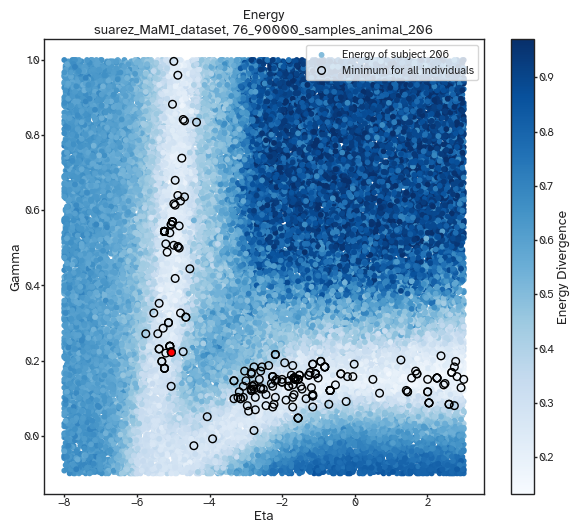

In [14]:
plt.figure(figsize=(viz.cm_to_inch((18,15))))

id = 0

if mode == "portrait":
    df = df_portraits.copy() 
    important_parameter = f"PortraitDiv_indiv_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
else: 
    print("Mode not recognized")

df_avg = df.groupby(['eta', 'gamma'], as_index=False).agg({
    important_parameter: 'mean'
})

plt.scatter(df["eta"], df["gamma"], c=df[important_parameter], alpha=1, s=10, cmap="Blues", label=f"{mode.capitalize()} of subject {206}")

plt.colorbar(label=f"{mode.capitalize()} Divergence")

plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c=None, # "cyan",
    alpha=1,
    edgecolors="black", 
    linewidths=1, 
    facecolors='none',
    s=30,
    label="Minimum for all individuals",
)   


plt.scatter(
    df_best_eta_gamma.loc[206, "eta"],
    df_best_eta_gamma.loc[206, "gamma"],
    c="red",
    alpha=1,
    edgecolors="black", 
    linewidths=1, 
    s=30)
plt.title(f"{mode.capitalize()}\n{DATASET_NAME}, {PROJECT_NAME}")

plt.legend(loc="upper right") #  bbox_to_anchor=(0,0)) # , fontsize=12)
x_label = "Eta"
y_label = "Gamma"
plt.xlabel(x_label)
plt.ylabel(y_label)

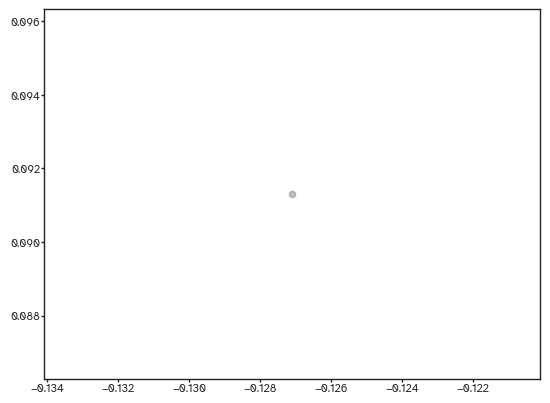

In [ ]:
import matplotlib.pyplot as plt 

plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c="gray",
    alpha=0.5,
    s=20,
    label="All subjects",
)   

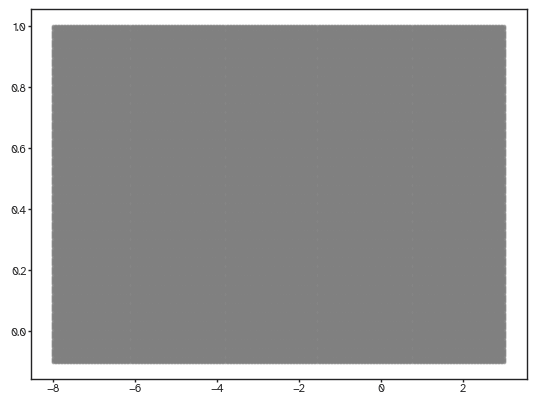

In [ ]:
plt.scatter(
    df["eta"],
    df["gamma"],
    c="gray",
    alpha=0.5,
    s=3,
    label="All subjects",
)

In [ ]:
# metric_type = "portrait_divergence"  # 
# # metric_type = "energy"

# for id in range(100):

#     plt.figure(figsize=(viz.cm_to_inch((18,18))))

#     if metric_type == "energy":
#         parameter_name = f"MaxCrit_indiv_{id}"
#         cmap = "Blues"
#         name = "MaxCrit"
        
#         # Group by eta and gamma, then average the MaxCriteria column
#         df_plotable = df_energies.groupby(['eta', 'gamma'], as_index=False).agg({
#             parameter_name: 'mean'
#         })
        
        
#     elif metric_type == "portrait_divergence":
#         parameter_name = f"PortraitDiv_indiv_{id}"
#         cmap = "Greens"
#         name = "PortraitDiv"
        
#         # Group by eta and gamma, then average the MaxCriteria column
#         df_plotable = df_portraits_2.groupby(['eta', 'gamma'], as_index=False).agg({
#             parameter_name: 'mean'
#         })
    
#     plt.scatter(df_plotable["eta"], df_plotable["gamma"], c=df_plotable[parameter_name], alpha=1, s=15, cmap=cmap) # hot")
#     plt.ylim(0,1)
    
    

#     # plt.scatter(
#     #     df_best_eta_gamma["eta"],
#     #     df_best_eta_gamma["gamma"],
#     #     c="cyan",
#     #     alpha=0.4,
#     #     edgecolors="cyan", 
#     #     linewidths=2, 
#     #     s=20,
#     #     label="All subjects",
#     # )   
#     plt.scatter(
#         df_best_eta_gamma["eta"],
#         df_best_eta_gamma["gamma"],
#         c=None, # "cyan",
#         alpha=1,
#         edgecolors="black", # "cyan", 
#         linewidths=1, 
#         facecolors='none',
#         s=30,
#         label="All subjects",
#     )   

#     plt.title(f"{name}, HCP, Subject {id}")
    
#     # plt.gca().set_aspect('equal')

#     plt.savefig(save_path_divergence / f"{name.lower()}_{id}.pdf")
#     if id == 0:
#         print(save_path_divergence / f"{name.lower()}_{id}.pdf")
        
#     plt.close()
        
        

In [ ]:
# # metric_type = "portrait_divergence"  # 
# metric_type = "energy"

# for id in range(100):

#     plt.figure(figsize=(viz.cm_to_inch((18,18))))

#     if metric_type == "energy":
#         parameter_name = f"MaxCrit_indiv_{id}"
#         cmap = "Blues"
#         name = "MaxCrit"
        
#         # Group by eta and gamma, then average the MaxCriteria column
#         df_plotable = df_energies.groupby(['eta', 'gamma'], as_index=False).agg({
#             parameter_name: 'mean'
#         })
        
        
#     elif metric_type == "portrait_divergence":
#         parameter_name = f"PortraitDiv_indiv_{id}"
#         cmap = "Greens"
#         name = "PortraitDiv"
        
#         # Group by eta and gamma, then average the MaxCriteria column
#         df_plotable = df_portraits_2.groupby(['eta', 'gamma'], as_index=False).agg({
#             parameter_name: 'mean'
#         })
    
#     plt.scatter(df_plotable["eta"], df_plotable["gamma"], c=df_plotable[parameter_name], alpha=1, s=15, cmap=cmap) # hot")
#     plt.ylim(0,1)
    
    

#     # plt.scatter(
#     #     df_best_eta_gamma["eta"],
#     #     df_best_eta_gamma["gamma"],
#     #     c="cyan",
#     #     alpha=0.4,
#     #     edgecolors="cyan", 
#     #     linewidths=2, 
#     #     s=20,
#     #     label="All subjects",
#     # )   
#     plt.scatter(
#         df_best_eta_gamma["eta"],
#         df_best_eta_gamma["gamma"],
#         c=None, # "cyan",
#         alpha=1,
#         edgecolors="black", # "cyan", 
#         linewidths=1, 
#         facecolors='none',
#         s=30,
#         label="All subjects",
#     )   

#     plt.title(f"{name}, HCP, Subject {id}")
    
#     # plt.gca().set_aspect('equal')

#     plt.savefig(save_path_divergence / f"{name.lower()}_{id}.pdf")
#     if id == 0:
#         print(save_path_divergence / f"{name.lower()}_{id}.pdf")
        
#     plt.close()
        
        

In [ ]:
# plt.figure(figsize=(8,8)) # viz.cm_to_inch((9, 9))))

# plt.scatter(df_metrics["eta"], df_metrics["gamma"], c=df_metrics["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=1, s=10, cmap="hot")

# plt.scatter(
#     df_best_eta_gamma["eta"],
#     df_best_eta_gamma["gamma"],
#     c="cyan",
#     alpha=0.4,
#     edgecolors="cyan", 
#     linewidths=2, 
#     s=20,
#     label="All subjects",
# )   

# plt.scatter(
#     df_best_eta_gamma["eta"],
#     df_best_eta_gamma["gamma"],
#     c=None, # "cyan",
#     alpha=1,
#     edgecolors="cyan", 
#     linewidths=1, 
#     facecolors='none',
#     s=30,
#     label="All subjects",
# )   


# plt.title("Estimated best fitting GNM parameters for HCP subjects in HCP distance matrix landscape")

In [ ]:
# blue_data, eta_edges, gamma_edges = np.histogram2d(
#     df_energies["eta"], 
#     df_energies["gamma"], 
#     bins=[100,100], 
#     # bins=[eta_bins, gamma_bins],
#     weights=df_energies["MaxCrit_indiv_1"]
# )
# # normalize data for visualization
# blue_norm = (blue_data - np.nanmin(blue_data)) / (np.nanmax(blue_data) - np.nanmin(blue_data))

# green_data, eta_edges, gamma_edges = np.histogram2d(
#     df_portraits["eta"], 
#     df_portraits["gamma"], 
#     bins=[100,100],
#     # bins=[eta_bins, gamma_bins],
#     weights=df_portraits["PortraitDiv_indiv_1"]
# )
# # normalize data for visualization
# green_norm = (green_data - np.nanmin(green_data)) / (np.nanmax(green_data) - np.nanmin(green_data))

# blue_data.shape, eta_edges.shape, gamma_edges.shape, eta_edges

KeyError: 'PortraitDiv_indiv_1'

In [ ]:
# # Create RGB image (transpose to match imshow's orientation)
# rgb_image = np.zeros((100, 100, 3))
# rgb_image[:, :, 2] = green_norm.T  # Red channel
# rgb_image[:, :, 1] = blue_norm.T  # green (1) or Blue (2) channel


(0.0, 20.0)

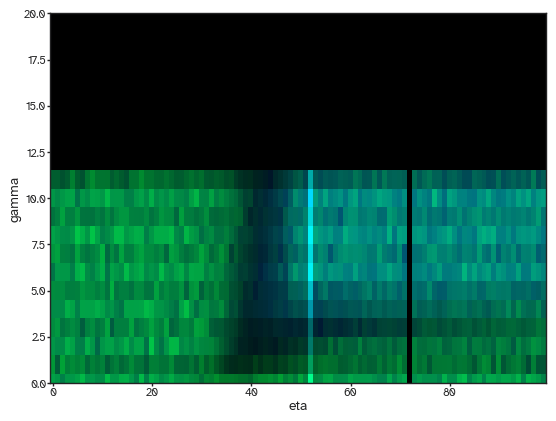

In [ ]:
# plt.imshow(rgb_image, origin='lower', aspect="auto") # , extent=[0, 0.1, -8, 3]) # , aspect='')
# plt.xlabel('eta')
# plt.ylabel('gamma')
# plt.ylim(0, 20)
# # plt.title('Overlay: Blue = MaxCrit_indiv_1, Red = MaxCriteria (combined)')

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define the binning parameters
# # n_bins = 99

# # # Get the ranges for binning (use combined min/max to ensure same grid)
# # eta_min = min(df_indiv_76["eta"].min(), df_all_metrics_76["eta"].min())
# # eta_max = max(df_indiv_76["eta"].max(), df_all_metrics_76["eta"].max())
# # gamma_min = min(df_indiv_76["gamma"].min(), df_all_metrics_76["gamma"].min())
# # gamma_max = max(df_indiv_76["gamma"].max(), df_all_metrics_76["gamma"].max())

# # Create bins
# eta_bins = np.linspace(eta_min, eta_max, n_bins + 1)
# gamma_bins = np.linspace(gamma_min, gamma_max, n_bins + 1)

# # Bin the data and compute mean values in each bin
# # For blue channel (df_indiv_76)
# blue_data, eta_edges, gamma_edges = np.histogram2d(
#     df_indiv_76["eta"], 
#     df_indiv_76["gamma"], 
#     bins=[eta_bins, gamma_bins],
#     weights=df_indiv_76["MaxCrit_indiv_1"]
# )
# blue_counts, _, _ = np.histogram2d(
#     df_indiv_76["eta"], 
#     df_indiv_76["gamma"], 
#     bins=[eta_bins, gamma_bins]
# )
# blue_mean = np.divide(blue_data, blue_counts, where=blue_counts>0, out=np.zeros_like(blue_data))

# # For red channel (df_all_metrics_76)
# red_data, _, _ = np.histogram2d(
#     df_all_metrics_76["eta"], 
#     df_all_metrics_76["gamma"], 
#     bins=[eta_bins, gamma_bins],
#     weights=df_all_metrics_76["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]
# )
# red_counts, _, _ = np.histogram2d(
#     df_all_metrics_76["eta"], 
#     df_all_metrics_76["gamma"], 
#     bins=[eta_bins, gamma_bins]
# )
# red_mean = np.divide(red_data, red_counts, where=red_counts>0, out=np.zeros_like(red_data))

# # Normalize to [0, 1] range
# blue_norm = (blue_mean - np.nanmin(blue_mean[blue_counts > 0])) / (np.nanmax(blue_mean[blue_counts > 0]) - np.nanmin(blue_mean[blue_counts > 0]))
# red_norm = (red_mean - np.nanmin(red_mean[red_counts > 0])) / (np.nanmax(red_mean[red_counts > 0]) - np.nanmin(red_mean[red_counts > 0]))

# # Replace NaNs with 0
# blue_norm = np.nan_to_num(blue_norm)
# red_norm = np.nan_to_num(red_norm)

# # Create RGB image (transpose to match imshow's orientation)
# rgb_image = np.zeros((100, 100, 3))
# rgb_image[:, :, 2] = red_norm.T  # Red channel
# rgb_image[:, :, 1] = blue_norm.T  # green (1) or Blue (2) channel

# # Plot
# # plt.figure(figsize=(10, 8))
# plt.imshow(rgb_image, origin='lower', extent=[eta_min, eta_max, gamma_min, gamma_max], aspect='auto')
# plt.xlabel('eta')
# plt.ylabel('gamma')
# plt.title('Overlay: Blue = MaxCrit_indiv_1, Red = MaxCriteria (combined)')

# # Add custom legend
# from matplotlib.patches import Patch
# legend_elements = [
#     Patch(facecolor='blue', label='MaxCrit_indiv_1 (high values)'),
#     Patch(facecolor='red', label='MaxCriteria combined (high values)'),
#     Patch(facecolor='magenta', label='Both high (overlap)')
# ]
# plt.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()


# print(f"Blue channel min: {df_indiv_76['MaxCrit_indiv_1'].min()}")
# print(f"Red channel min: {df_all_metrics_76['MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'].min()}")

# plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

Text(0.5, 1.0, 'Estimated best fitting GNM parameters for HCP subjects in HCP distance matrix landscape')

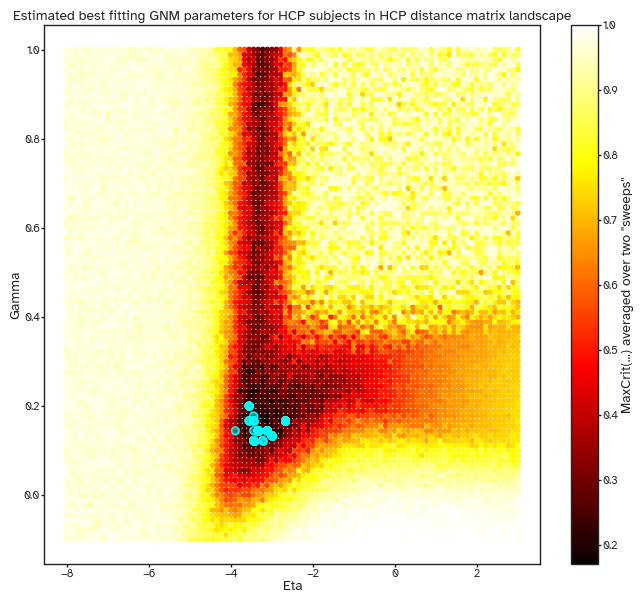

In [ ]:
# # Group by eta and gamma, then average the MaxCriteria column
# df_metrics_avg = df_metrics.groupby(['eta', 'gamma'], as_index=False).agg({
#     'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)': 'mean'
# })

# plt.figure(figsize=(8,7))

# # Use the averaged dataframe for the scatter plot
# plt.scatter(
#     df_metrics_avg["eta"], 
#     df_metrics_avg["gamma"], 
#     c=df_metrics_avg["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], 
#     alpha=1, 
#     s=10, 
#     cmap="hot"
# )

# plt.colorbar(label='MaxCrit(...) averaged over two "sweeps"')

# plt.scatter(
#     df_best_eta_gamma["eta"],
#     df_best_eta_gamma["gamma"],
#     c="cyan",
#     alpha=0.4,
#     edgecolors="cyan", 
#     linewidths=2, 
#     s=20,
#     label="All subjects",
# )   

# plt.scatter(
#     df_best_eta_gamma["eta"],
#     df_best_eta_gamma["gamma"],
#     c=None,
#     alpha=1,
#     edgecolors="cyan", 
#     linewidths=1, 
#     facecolors='none',
#     s=30,
#     label="All subjects",
# )   

# plt.ylabel("Gamma")
# plt.xlabel("Eta")
# plt.title("Estimated best fitting GNM parameters for HCP subjects in HCP distance matrix landscape")

(array([ 1., 13., 25., 29., 12.,  2., 11.,  6.,  0.,  1.]),
 array([0.10000002, 0.10800002, 0.11600002, 0.12400001, 0.13200001,
        0.14000001, 0.148     , 0.156     , 0.164     , 0.172     ,
        0.17999999]),
 <BarContainer object of 10 artists>)

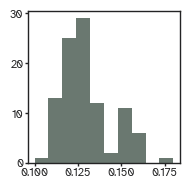

In [ ]:
plt.figure(figsize=(viz.cm_to_inch((5,5))))

plt.hist(df_best_eta_gamma["energy"])


# Individual connectome fits

In [ ]:
df_indiv_76 = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv") 
df_all_metrics_76 = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/all_metrics_for_76_90000_samples_animal_206.csv")

In [ ]:
df_indiv.head()

,network_index,filename,eta,gamma,id,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,...,MaxCrit_indiv_90,MaxCrit_indiv_91,MaxCrit_indiv_92,MaxCrit_indiv_93,MaxCrit_indiv_94,MaxCrit_indiv_95,MaxCrit_indiv_96,MaxCrit_indiv_97,MaxCrit_indiv_98,MaxCrit_indiv_99
0,0,net_eta-1.488294363021851_gamma0.0287625398486...,-1.488294,0.028763,0,0.900000,0.890000,0.920000,0.900000,0.930000,...,0.890000,0.900000,0.910000,0.920000,0.910000,0.900000,0.910000,0.910000,0.880000,0.920000
1,1,net_eta2.558528423309326_gamma0.46287626028060...,2.558528,0.462876,0,0.860000,0.880000,0.920000,0.930000,0.850000,...,0.890000,0.900000,0.890000,0.900000,0.900000,0.850000,0.900000,0.880000,0.880000,0.880000
2,2,net_eta2.264214038848877_gamma0.44448161125183...,2.264214,0.444482,0,0.760000,0.770000,0.770000,0.870000,0.760000,...,0.790000,0.770000,0.780000,0.770000,0.760000,0.770000,0.820000,0.760000,0.770000,0.780000
3,3,net_eta2.337792634963989_gamma0.79397994279861...,2.337793,0.793980,0,0.930000,0.920000,0.930000,0.950000,0.920000,...,0.940000,0.930000,0.940000,0.930000,0.940000,0.900000,0.940000,0.900000,0.930000,0.930000
4,4,net_eta2.337792634963989_gamma0.28260868787765...,2.337793,0.282609,0,0.567677,0.575758,0.606061,0.626263,0.593939,...,0.565657,0.579798,0.620202,0.616162,0.585859,0.624242,0.606061,0.591919,0.565657,0.614141


In [ ]:
# remove row with id == 496
df_indiv = df_indiv[df_indiv.index != 496]

In [ ]:
best_fit_index_arr = [] 
for i in range(100): 
    # get the id of df_indiv[f"MaxCrit_indiv_{i}"].min()
   best_fit_index = df_indiv[df_indiv[f"MaxCrit_indiv_{i}"] == df_indiv[f"MaxCrit_indiv_{i}"].min()].index[0]
   print(best_fit_index)
   best_fit_index_arr.append(best_fit_index)
#    print(df_indiv.iloc[best_fit_index])

7189
2090
2090
7189
2090
7189
2090
2090
7189
7189
2090
7189
7189
2090
2090
4243
2090
2090
7189
2090
7189
2090
7189
2090
1929
2090
2090
8812
7189
2090
2090
2090
2090
1929
7189
4243
7189
2090
2090
7189
2090
1929
7189
2090
2090
2090
2090
2090
4243
7189
2090
2090
2090
1929
4243
7189
2090
1929
7189
7189
7189
7189
2090
2090
7189
7189
2090
7189
2090
7189
7189
501
1929
1929
2090
1929
2090
2090
1929
2090
2090
2090
2090
2090
2090
2090
4243
7189
1929
7189
7189
7189
7189
2090
2090
7189
7189
7189
7189
2090


(array([ 1.,  0.,  0.,  0.,  0., 58.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 35.,  0.,
         0.,  0.,  0.,  1.]),
 array([ 501.        ,  778.03333333, 1055.06666667, 1332.1       ,
        1609.13333333, 1886.16666667, 2163.2       , 2440.23333333,
        2717.26666667, 2994.3       , 3271.33333333, 3548.36666667,
        3825.4       , 4102.43333333, 4379.46666667, 4656.5       ,
        4933.53333333, 5210.56666667, 5487.6       , 5764.63333333,
        6041.66666667, 6318.7       , 6595.73333333, 6872.76666667,
        7149.8       , 7426.83333333, 7703.86666667, 7980.9       ,
        8257.93333333, 8534.96666667, 8812.        ]),
 <BarContainer object of 30 artists>)

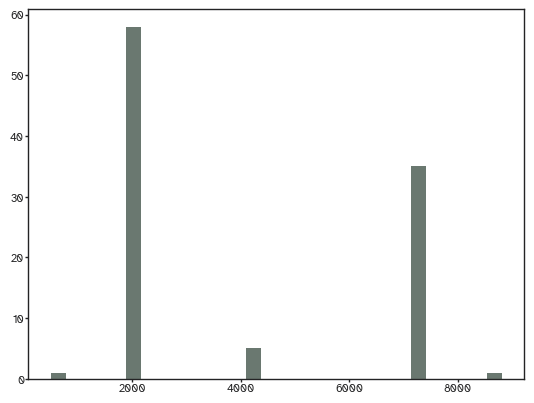

In [ ]:
plt.hist(best_fit_index_arr, bins=30)

In [ ]:
set(best_fit_index_arr)

{np.int64(501),
 np.int64(1929),
 np.int64(2090),
 np.int64(4243),
 np.int64(7189),
 np.int64(8812)}

In [ ]:
# Get df with the indexes of best_fit_index_arr
df_indiv_best = df_indiv[df_indiv.index.isin(best_fit_index_arr)]
df_indiv_best

,network_index,filename,eta,gamma,id,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,...,MaxCrit_indiv_90,MaxCrit_indiv_91,MaxCrit_indiv_92,MaxCrit_indiv_93,MaxCrit_indiv_94,MaxCrit_indiv_95,MaxCrit_indiv_96,MaxCrit_indiv_97,MaxCrit_indiv_98,MaxCrit_indiv_99
501,373,net_eta-3.107023239135742_gamma0.4040133655071...,-3.107023,0.404013,0,0.436364,0.470000,0.500000,0.580000,0.480000,...,0.460000,0.500000,0.500000,0.472727,0.458586,0.494950,0.500000,0.468687,0.450000,0.520000
1929,1801,net_eta-4.17391300201416_gamma0.81973242759704...,-4.173913,0.819732,0,0.440404,0.446465,0.466667,0.488889,0.450505,...,0.434343,0.430303,0.488889,0.470707,0.460606,0.496970,0.470707,0.472727,0.438384,0.488889
2090,1962,net_eta-4.431437969207764_gamma0.4702341258525...,-4.431438,0.470234,0,0.434343,0.444444,0.462626,0.482828,0.448485,...,0.432323,0.428283,0.484848,0.468687,0.454545,0.492929,0.464646,0.466667,0.432323,0.486869
4243,4115,net_eta-3.033444881439209_gamma0.2494983226060...,-3.033445,0.249498,0,0.442424,0.448485,0.468687,0.490909,0.454545,...,0.442424,0.430303,0.496970,0.474747,0.466667,0.498990,0.474747,0.470707,0.444444,0.486869
7189,7061,net_eta-3.438127040863037_gamma0.2678929865360...,-3.438127,0.267893,0,0.434343,0.446465,0.462626,0.482828,0.448485,...,0.430303,0.426263,0.482828,0.472727,0.454545,0.490909,0.460606,0.464646,0.432323,0.486869
8812,8684,net_eta-1.7826087474823_gamma0.21270902454853_...,-1.782609,0.212709,0,0.440404,0.448485,0.466667,0.486869,0.452525,...,0.440404,0.432323,0.492929,0.474747,0.462626,0.496970,0.470707,0.468687,0.442424,0.490909


0.4323232471942901


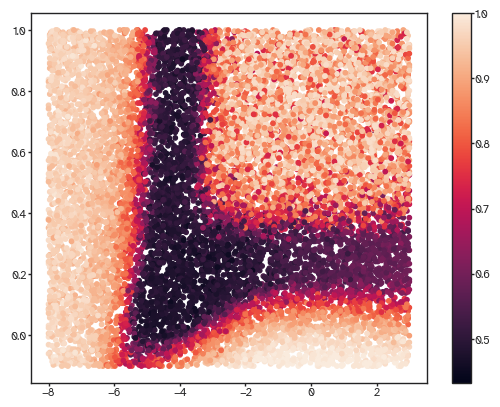

In [ ]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"], alpha=1, s=10) 
plt.colorbar()
print(df_indiv["MaxCrit_indiv_1"].min())

0.4323232471942901


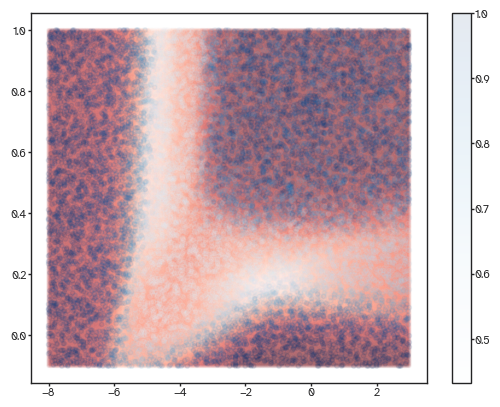

In [ ]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
plt.scatter(df_all_metrics_76["eta"], df_all_metrics_76["gamma"], c=df_all_metrics_76["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap="Reds", alpha=0.05, s=5)
plt.scatter(df_indiv_76["eta"], df_indiv_76["gamma"], c=df_indiv_76["MaxCrit_indiv_1"], cmap="Blues", alpha=0.1, s=10) 

plt.colorbar()
print(df_indiv_76["MaxCrit_indiv_1"].min())

In [ ]:
df_indiv = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/00_default_animal_0/all_metrics_for_00_default_animal_0.csv") 

# plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"] == df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].min()][["eta", "gamma", "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]]
# plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7615658824455241..1.0].


Blue channel min: 0.4323232471942901
Red channel min: 0.0799999982118606


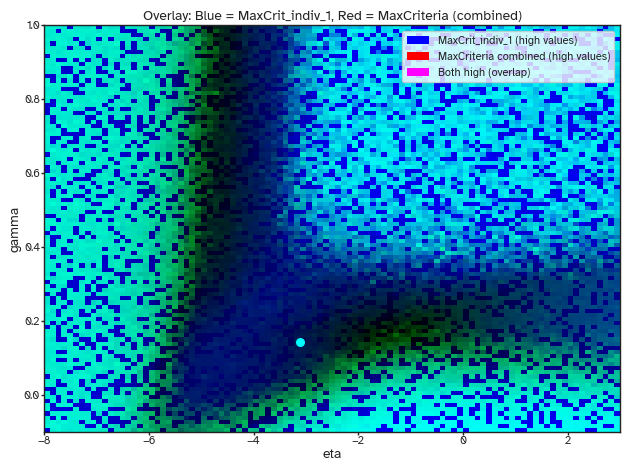

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the binning parameters
n_bins = 99

# Get the ranges for binning (use combined min/max to ensure same grid)
eta_min = min(df_indiv_76["eta"].min(), df_all_metrics_76["eta"].min())
eta_max = max(df_indiv_76["eta"].max(), df_all_metrics_76["eta"].max())
gamma_min = min(df_indiv_76["gamma"].min(), df_all_metrics_76["gamma"].min())
gamma_max = max(df_indiv_76["gamma"].max(), df_all_metrics_76["gamma"].max())

# Create bins
eta_bins = np.linspace(eta_min, eta_max, n_bins + 1)
gamma_bins = np.linspace(gamma_min, gamma_max, n_bins + 1)

# Bin the data and compute mean values in each bin
# For blue channel (df_indiv_76)
blue_data, eta_edges, gamma_edges = np.histogram2d(
    df_indiv_76["eta"], 
    df_indiv_76["gamma"], 
    bins=[eta_bins, gamma_bins],
    weights=df_indiv_76["MaxCrit_indiv_1"]
)
blue_counts, _, _ = np.histogram2d(
    df_indiv_76["eta"], 
    df_indiv_76["gamma"], 
    bins=[eta_bins, gamma_bins]
)
blue_mean = np.divide(blue_data, blue_counts, where=blue_counts>0, out=np.zeros_like(blue_data))

# For red channel (df_all_metrics_76)
red_data, _, _ = np.histogram2d(
    df_all_metrics_76["eta"], 
    df_all_metrics_76["gamma"], 
    bins=[eta_bins, gamma_bins],
    weights=df_all_metrics_76["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]
)
red_counts, _, _ = np.histogram2d(
    df_all_metrics_76["eta"], 
    df_all_metrics_76["gamma"], 
    bins=[eta_bins, gamma_bins]
)
red_mean = np.divide(red_data, red_counts, where=red_counts>0, out=np.zeros_like(red_data))

# Normalize to [0, 1] range
blue_norm = (blue_mean - np.nanmin(blue_mean[blue_counts > 0])) / (np.nanmax(blue_mean[blue_counts > 0]) - np.nanmin(blue_mean[blue_counts > 0]))
red_norm = (red_mean - np.nanmin(red_mean[red_counts > 0])) / (np.nanmax(red_mean[red_counts > 0]) - np.nanmin(red_mean[red_counts > 0]))

# Replace NaNs with 0
blue_norm = np.nan_to_num(blue_norm)
red_norm = np.nan_to_num(red_norm)

# Create RGB image (transpose to match imshow's orientation)
rgb_image = np.zeros((n_bins, n_bins, 3))
rgb_image[:, :, 2] = red_norm.T  # Red channel
rgb_image[:, :, 1] = blue_norm.T  # green (1) or Blue (2) channel

# Plot
# plt.figure(figsize=(10, 8))
plt.imshow(rgb_image, origin='lower', extent=[eta_min, eta_max, gamma_min, gamma_max], aspect='auto')
plt.xlabel('eta')
plt.ylabel('gamma')
plt.title('Overlay: Blue = MaxCrit_indiv_1, Red = MaxCriteria (combined)')

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='MaxCrit_indiv_1 (high values)'),
    Patch(facecolor='red', label='MaxCriteria combined (high values)'),
    Patch(facecolor='magenta', label='Both high (overlap)')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()


print(f"Blue channel min: {df_indiv_76['MaxCrit_indiv_1'].min()}")
print(f"Red channel min: {df_all_metrics_76['MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'].min()}")

plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

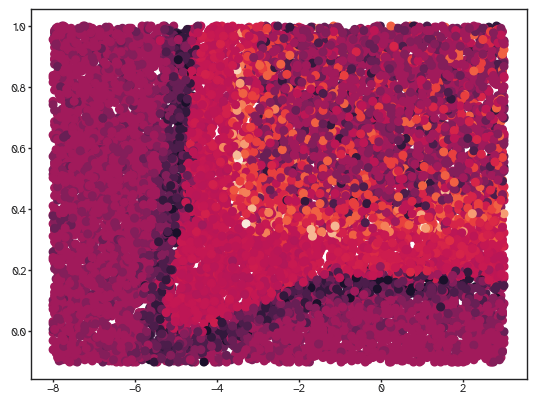

In [ ]:
# plt.scatter(df_indiv["MaxCrit_indiv_0"], df_indiv["MaxCrit_indiv_1"], c=df_indiv["eta"], alpha=1, s=30) 
# plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"]-df_indiv["MaxCrit_indiv_0"], alpha=1, s=30) 
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"]-df_indiv["MaxCrit_indiv_0"], alpha=1, s=30) 

In [ ]:
best_fits_df = {} #  pd.DataFrame()
for i in range(10): 
    df_indiv_best_0 = df_indiv[df_indiv[f"MaxCrit_indiv_{i}"] == df_indiv[f"MaxCrit_indiv_{i}"].min()][["eta", "gamma", f"MaxCrit_indiv_{i}"]]
    best_fits_df[i] = df_indiv_best_0

best_fits_df = pd.concat(best_fits_df.values(), ignore_index=True)
best_fits_df.head()

,eta,gamma,MaxCrit_indiv_0,MaxCrit_indiv_1,MaxCrit_indiv_2,MaxCrit_indiv_3,MaxCrit_indiv_4,MaxCrit_indiv_5,MaxCrit_indiv_6,MaxCrit_indiv_7,MaxCrit_indiv_8,MaxCrit_indiv_9
0,-4.35786,0.334114,0.420202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-4.35786,0.334114,NaN,0.432323,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-4.35786,0.334114,NaN,NaN,0.450505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-4.35786,0.334114,NaN,NaN,NaN,0.468687,NaN,NaN,NaN,NaN,NaN,NaN
4,-4.35786,0.334114,NaN,NaN,NaN,NaN,0.438384,NaN,NaN,NaN,NaN,NaN


In [ ]:

plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_0"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()][["eta", "gamma", "MaxCrit_indiv_1"]]
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

NameError: name 'df_indiv' is not defined

In [ ]:
# get the row and index of df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()][["eta", "gamma", "MaxCrit_indiv_1"]]

# best_fit_index_1 = df_indiv_best_1.index[1]
# best_fit_row_1 = df_indiv_best_1.iloc[1]
best_fit_row_1 = df_indiv_best_1 # .iloc[1]
best_fit_row_1

,eta,gamma,MaxCrit_indiv_1
496,-4.35786,0.334114,0.432323


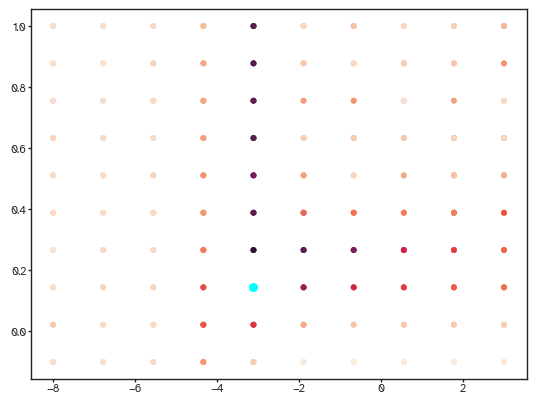

In [ ]:
df_indiv = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/00_default_animal_0/all_metrics_for_00_default_animal_0.csv") 

plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], alpha=0.5, s=10)
# df_indiv_best_0 = df_indiv[df_indiv["MaxCrit_indiv_0"] == df_indiv["MaxCrit_indiv_0"].min()]
df_indiv_best_1 = df_indiv[df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"] == df_indiv["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"].min()][["eta", "gamma", "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"]]
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

In [ ]:
plt.scatter(df_indiv["eta"], df_indiv["gamma"], c=df_indiv["MaxCrit_indiv_1"], alpha=0.5, s=10, cmap="hot")
df_indiv_best_1 = df_indiv[df_indiv["MaxCrit_indiv_1"] == df_indiv["MaxCrit_indiv_1"].min()]
df_indiv_best_1.head()
plt.scatter(df_indiv_best_1["eta"], df_indiv_best_1["gamma"], c="cyan", alpha=1, s=30)

plt.title("One human connectome fit to GNMs generated with animal 0's distance matrix")

KeyError: 'MaxCrit_indiv_1'

In [ ]:
best_fit_row_1["MaxCrit_indiv_0"].values

array([0.42020205])

In [ ]:
df_indiv_best_1["diff_between_0_and_1"] = df_indiv_best_1["MaxCrit_indiv_1"].values - best_fit_row_1["MaxCrit_indiv_0"].values 

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_3675/2550699675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_indiv_best_1["diff_between_0_and_1"] = df_indiv_best_1["MaxCrit_indiv_1"].values - best_fit_row_1["MaxCrit_indiv_0"].values # + np.abs(df_indiv_best_1["gamma"] - best_fit_row_1["gamma"].values[0])


In [ ]:
df_indiv["MaxCrit_indiv_0"]

0        0.900000
1        0.860000
2        0.760000
3        0.930000
4        0.567677
           ...   
12222    0.503030
12223    0.980000
12224    0.950000
12225    0.770000
12226    0.484848
Name: MaxCrit_indiv_0, Length: 12227, dtype: float64

In [ ]:
df_indiv["MaxCrit_indiv_0"].min(), 

(np.float64(0.4202020466327667),)

# Distance Matrices


In [ ]:
from src.visualization.find_and_plot_closest_connectome import reorder_connectome_blockwise


In [ ]:
d_humans = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/02_distance_matrices/distance_matrix_100.npy")
d_mami = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_orig.npy")
d_mami_downsampled = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")


Processing block [0:50] with method: modularity
Processing block [50:100] with method: modularity
Processing block [0:100] with method: modularity
Processing block [100:200] with method: modularity
Processing block [0:50] with method: modularity
Processing block [50:100] with method: modularity


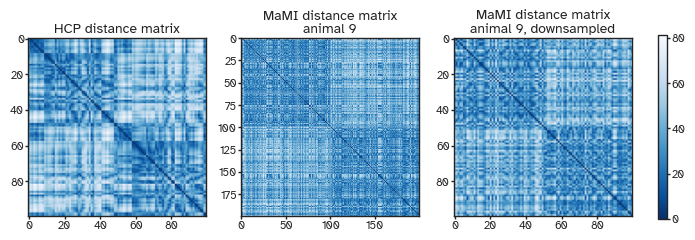

In [ ]:
animal_id = 9
d_show_human, _ = reorder_connectome_blockwise(d_humans, method="modularity", block_sizes=[50,50])
d_show_mami, _ = reorder_connectome_blockwise(d_mami[animal_id,:,:], method="modularity", block_sizes=[100,100])
d_show_mami_downsampled, _ = reorder_connectome_blockwise(d_mami_downsampled[animal_id,:,:], method="modularity") 


fig, axes = plt.subplots(1, 3, figsize=(viz.cm_to_inch((18,6))))

im1 = axes[0].imshow(d_humans, cmap="Blues_r")
axes[0].set_title("HCP distance matrix")

im2 = axes[1].imshow(d_mami[animal_id], cmap="Blues_r")
axes[1].set_title(f"MaMI distance matrix\nanimal {animal_id}")

im3 = axes[2].imshow(d_show_mami_downsampled, cmap="Blues_r")
axes[2].set_title(f"MaMI distance matrix\nanimal {animal_id}, downsampled")

# Add colorbar that spans the height of the subplots
plt.tight_layout()
cbar = fig.colorbar(im3, ax=axes, fraction=0.046, pad=0.04)

plt.show()